# Baseline LeNet-5 Model Reproduction

In [1]:
import torch
import numpy as np
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Pad(2),   # 28x28 -> 32x32
    transforms.ToTensor()
])

dataset = MNIST(root='data/', download=True, transform=transform)

In [3]:
len(dataset)

60000

In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [5]:
images, labels = next(iter(train_loader))

In [6]:
images.shape

torch.Size([8, 1, 32, 32])

In [7]:
# get the model
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('..'))

from models.lenet5 import LeNet5

model = LeNet5()

outputs = model(images)
print(outputs.shape)

torch.Size([8, 10])


In [8]:
pred = torch.argmin(outputs, dim=1)

print(pred)
print(labels)

tensor([6, 6, 6, 6, 6, 6, 6, 6])
tensor([9, 5, 7, 3, 5, 2, 6, 5])


In [9]:
loss = outputs.mean()
loss.backward()

In [10]:
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)
images, labels = next(iter(train_loader))
outputs = model(images)

pred = torch.argmin(outputs, dim=1)

print(pred)
print(labels)

tensor([6, 6, 6, 6, 6, 6, 6, 6])
tensor([0, 8, 5, 4, 5, 6, 9, 0])


## Setup Training 

In [11]:
from torch.utils.data import random_split

val_size = 10000
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(50000, 10000)

In [12]:
batch_size = 128

In [13]:
train_loader = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)

C:\Users\shehe\projects\ai-paper-reproductions\lenet-5\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


images.shape: torch.Size([128, 1, 32, 32])


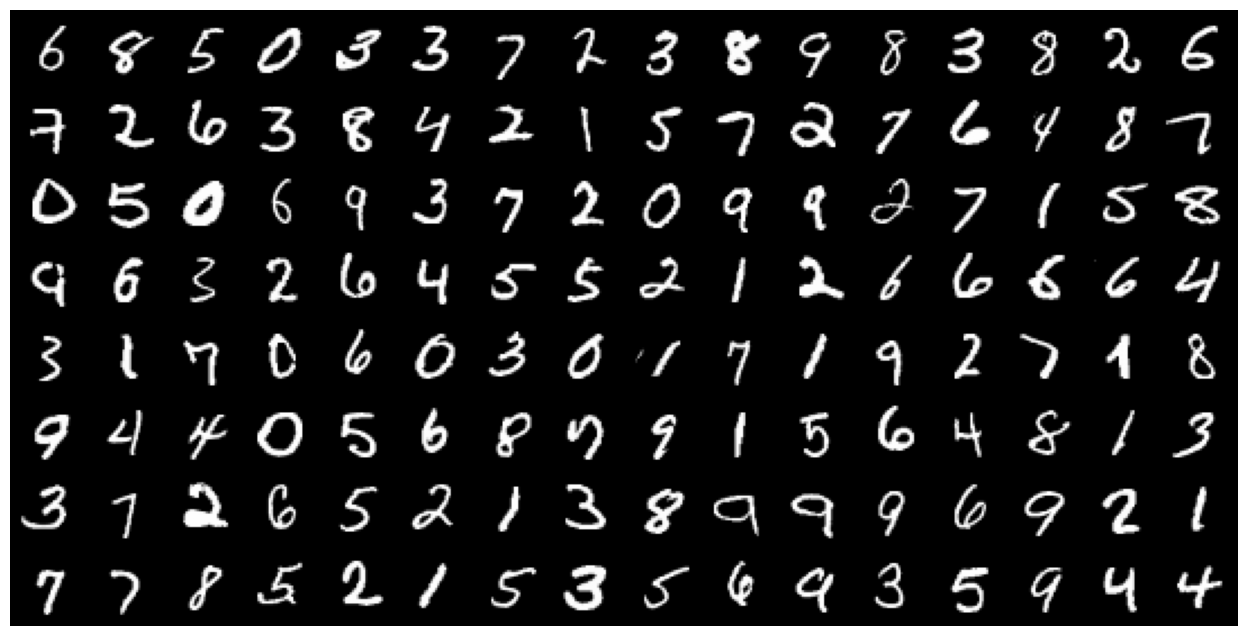

In [14]:
from torchvision.utils import make_grid

for images, _ in train_loader:
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,8))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1,2,0)))
    break

In [17]:
import models.lenet5

from models.lenet5 import LeNet5, fit
model = LeNet5()

history = fit(
    epochs=20,
    lr=0.01,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader
)

Epoch [0], val_loss: 0.6534, val_acc: 0.7781
Epoch [1], val_loss: 0.6423, val_acc: 0.7929
Epoch [2], val_loss: 0.7535, val_acc: 0.7395
Epoch [3], val_loss: 0.5797, val_acc: 0.8063
Epoch [4], val_loss: 0.3587, val_acc: 0.8971
Epoch [5], val_loss: 0.2935, val_acc: 0.9134
Epoch [6], val_loss: 0.2646, val_acc: 0.9274
Epoch [7], val_loss: 0.2319, val_acc: 0.9371
Epoch [8], val_loss: 0.1971, val_acc: 0.9429
Epoch [9], val_loss: 0.1974, val_acc: 0.9412
Epoch [10], val_loss: 0.2035, val_acc: 0.9390
Epoch [11], val_loss: 0.1452, val_acc: 0.9553
Epoch [12], val_loss: 0.1381, val_acc: 0.9559
Epoch [13], val_loss: 0.1266, val_acc: 0.9629
Epoch [14], val_loss: 0.1241, val_acc: 0.9632
Epoch [15], val_loss: 0.1352, val_acc: 0.9601
Epoch [16], val_loss: 0.1523, val_acc: 0.9553
Epoch [17], val_loss: 0.1156, val_acc: 0.9658
Epoch [18], val_loss: 0.1027, val_acc: 0.9693
Epoch [19], val_loss: 0.1021, val_acc: 0.9701


In [18]:
# save baseline model
torch.save(model.state_dict(), "lenet5_baseline.pth")

## Baseline LeNet-5 Model Metrics

1. Used **20 Epochs**
2. Validation Accuracy: **97.01%**
3. Validation Loss: **0.1021**

In [19]:
print(history)

[{'val_loss': 0.6533650755882263, 'val_acc': 0.778124988079071}, {'val_loss': 0.6423279047012329, 'val_acc': 0.7928711175918579}, {'val_loss': 0.7534767389297485, 'val_acc': 0.739453136920929}, {'val_loss': 0.5797269344329834, 'val_acc': 0.806347668170929}, {'val_loss': 0.3587367832660675, 'val_acc': 0.8970702886581421}, {'val_loss': 0.2935175895690918, 'val_acc': 0.913378894329071}, {'val_loss': 0.2645956873893738, 'val_acc': 0.927441418170929}, {'val_loss': 0.2318653166294098, 'val_acc': 0.9371093511581421}, {'val_loss': 0.19714388251304626, 'val_acc': 0.94287109375}, {'val_loss': 0.19739563763141632, 'val_acc': 0.941210925579071}, {'val_loss': 0.20348116755485535, 'val_acc': 0.93896484375}, {'val_loss': 0.14518548548221588, 'val_acc': 0.955273449420929}, {'val_loss': 0.13809055089950562, 'val_acc': 0.955859363079071}, {'val_loss': 0.12655317783355713, 'val_acc': 0.962890625}, {'val_loss': 0.12412784993648529, 'val_acc': 0.963183581829071}, {'val_loss': 0.13518154621124268, 'val_acc'

In [20]:
import pandas as pd

baseline_df = pd.DataFrame(history)

In [21]:
baseline_df

,val_loss,val_acc
0,0.653365,0.778125
1,0.642328,0.792871
2,0.753477,0.739453
3,0.579727,0.806348
4,0.358737,0.897070
5,0.293518,0.913379
6,0.264596,0.927441
7,0.231865,0.937109
8,0.197144,0.942871
9,0.197396,0.941211


In [35]:
baseline_df.index
print(baseline_df.index.tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


### Validation vs Loss Plot

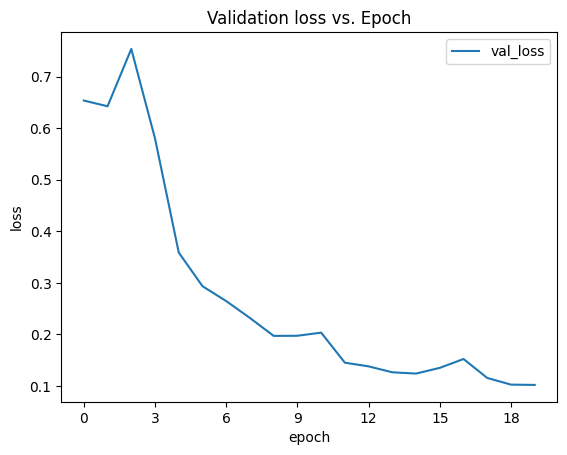

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 1. Plot your data
ax = baseline_df.plot(y='val_loss')

# 2. Force the X-axis to only use integers
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.ylabel('loss')
plt.title("Validation loss vs. Epoch")
plt.show()

### Accuracy vs Loss Plot

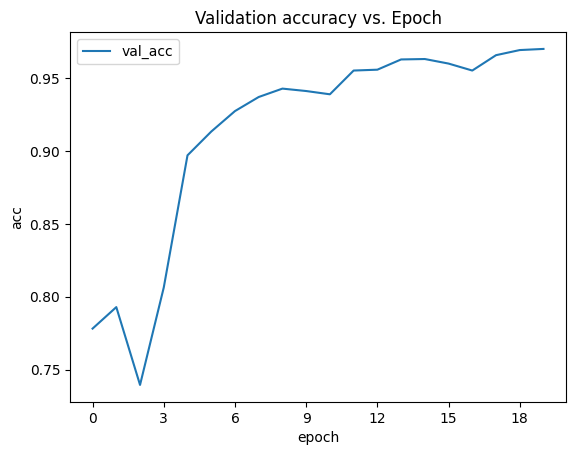

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 1. Plot your data
ax = baseline_df.plot(y='val_acc')

# 2. Force the X-axis to only use integers
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.ylabel('acc')
plt.title("Validation accuracy vs. Epoch")
plt.show()

## Baseline Model Configuration
- Architecture: LeNet-5 style CNN
- Activation: scaled tanh
- Pooling: average pooling
- Classifier: RBF with fixed prototypes
- Loss: MLE-style loss
- Optimizer: SGD
- Epochs: 20
- Final val accuracy: ~97.0%

## just seeing how lr affectes model perfomance

In [43]:
for lr in [0.005, 0.001]:
    model = LeNet5()
    print(f"lr = {lr}:")
    history = fit(
        epochs=20,
        lr=lr,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader
    )

lr = 0.005:


C:\Users\shehe\projects\ai-paper-reproductions\lenet-5\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [0], val_loss: 0.6154, val_acc: 0.8082
Epoch [1], val_loss: 0.5565, val_acc: 0.8232
Epoch [2], val_loss: 0.5598, val_acc: 0.8261
Epoch [3], val_loss: 0.4958, val_acc: 0.8515
Epoch [4], val_loss: 0.4491, val_acc: 0.8620
Epoch [5], val_loss: 0.4478, val_acc: 0.8669
Epoch [6], val_loss: 0.3583, val_acc: 0.8930
Epoch [7], val_loss: 0.3444, val_acc: 0.9007
Epoch [8], val_loss: 0.2982, val_acc: 0.9081
Epoch [9], val_loss: 0.2531, val_acc: 0.9249
Epoch [10], val_loss: 0.2784, val_acc: 0.9204
Epoch [11], val_loss: 0.2427, val_acc: 0.9298
Epoch [12], val_loss: 0.2000, val_acc: 0.9425
Epoch [13], val_loss: 0.1849, val_acc: 0.9474
Epoch [14], val_loss: 0.2022, val_acc: 0.9387
Epoch [15], val_loss: 0.1872, val_acc: 0.9450
Epoch [16], val_loss: 0.1563, val_acc: 0.9550
Epoch [17], val_loss: 0.1603, val_acc: 0.9521
Epoch [18], val_loss: 0.1542, val_acc: 0.9552
Epoch [19], val_loss: 0.1532, val_acc: 0.9551
lr = 0.001:
Epoch [0], val_loss: 0.8512, val_acc: 0.7209
Epoch [1], val_loss: 0.7570, val_

## Test Set Evaluation

In [44]:
# Define test set
test_dataset = MNIST(root='data/', train=False, transform=transform)

In [45]:
len(test_dataset)

10000

In [46]:
model.load_state_dict(torch.load('lenet5_baseline.pth'))

<All keys matched successfully>

In [49]:
from models.lenet5 import evaluate
test_loader = DataLoader(test_dataset, batch_size=256)
result = evaluate(model, test_loader)
result

{'val_loss': 0.0853935033082962, 'val_acc': 0.975390613079071}

# Baseline Results
- Dataset: MNIST (28×28 padded to 32×32)
- Architecture:
    - LeNet-5 style CNN
    - C1: 6 filters
    - C3: 16 filters
    - C5: 120 filters
    - F6: 84 units
- Activation: scaled tanh
- Pooling: average pooling
- Classifier: fixed RBF prototypes
- Loss: MLE-style objective
- Optimizer: SGD (lr=0.01)
- Epochs: 20
- Test accuracy: 97.54%
- Test loss: 0.085

## Visualizing Feature Maps

### C1 layer

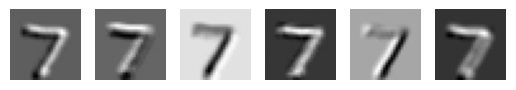

In [50]:
image, label = test_dataset[0]
image = image.unsqueeze(0)

feature_maps = model.C1(image)

fm = feature_maps.detach()

for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(fm[0,i], cmap="gray")
    plt.axis("off")

plt.show()

### C1 to C5 feature maps

In [52]:
import matplotlib.pyplot as plt

def show_feature_maps(tensor, max_maps=16):
    maps = tensor.detach().squeeze(0)
    n = min(maps.shape[0], max_maps)

    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols*2, rows*2))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(maps[i], cmap="gray")
        plt.axis("off")

    plt.show()

S1


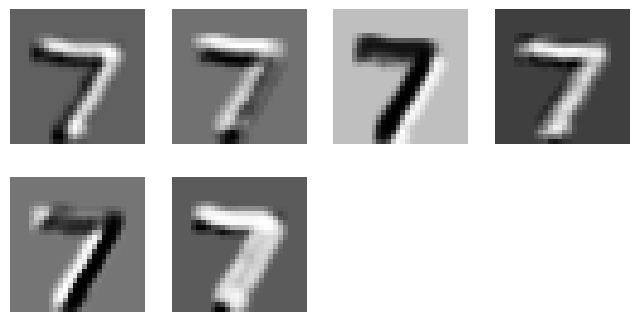


S2


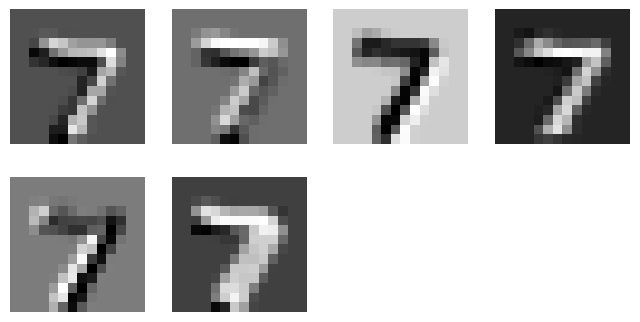


C3


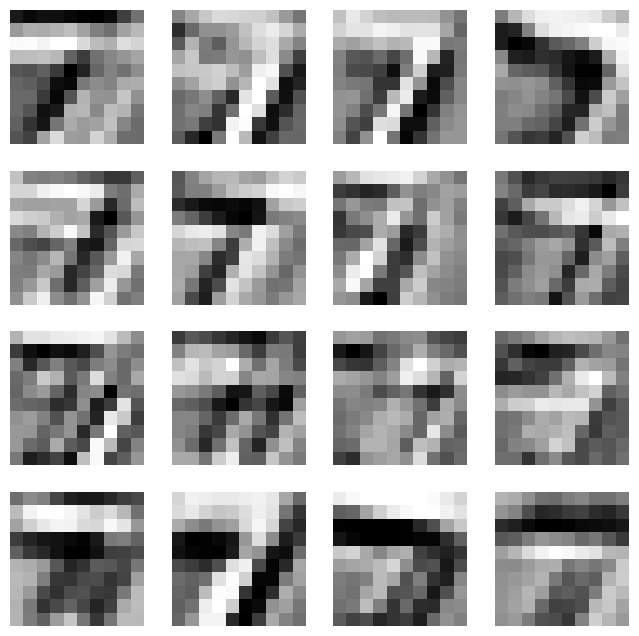


S4


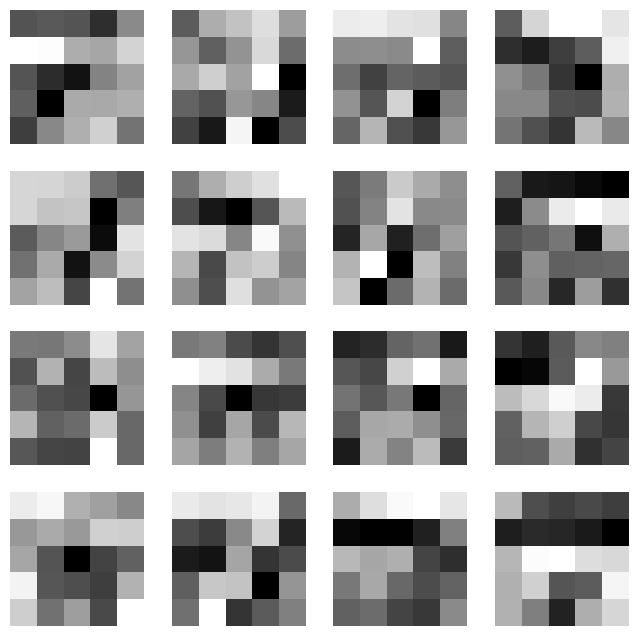


C5


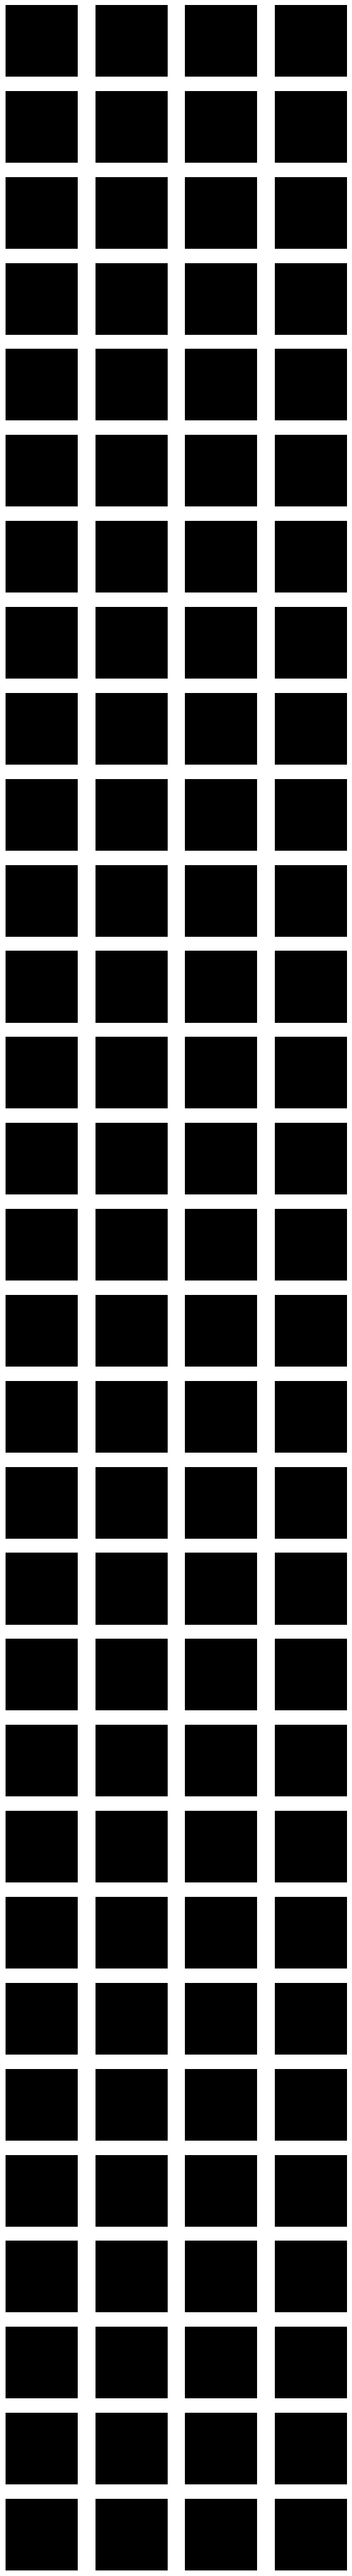

In [55]:
A = 1.7159
S = 2/3 
c1 = A * torch.tanh(S * model.C1(image))
s2 = model.S2(c1)
c3 = A * torch.tanh(S * model.C3(s2))
s4 = model.S4(c3)
c5 = A * torch.tanh(S * model.C5(s4))

print("S1")
show_feature_maps(c1, max_maps=6)
print("")

print("S2")
show_feature_maps(s2, max_maps=6)
print("")

print("C3")
show_feature_maps(c3, max_maps=16)
print("")

print("S4")
show_feature_maps(s4, max_maps=16)
print("")

print("C5")
show_feature_maps(c5, max_maps=120)
print("")

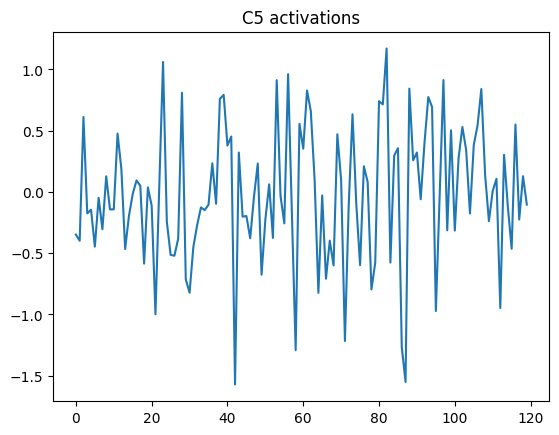

In [56]:
activations = c5.squeeze().detach()

plt.plot(activations)
plt.title("C5 activations")
plt.show()

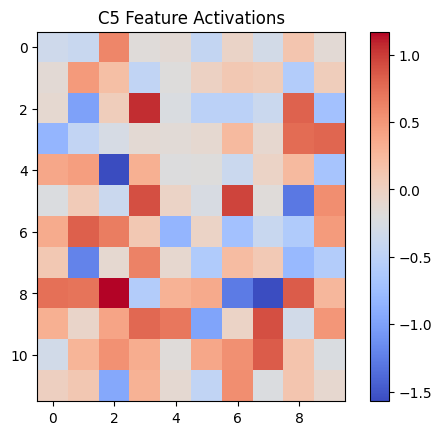

In [57]:
activations = c5.squeeze().detach().view(12,10)

plt.imshow(activations, cmap="coolwarm")
plt.title("C5 Feature Activations")
plt.colorbar()
plt.show()